--- Starting Lagrangian Relaxation for fault-tolerant p-median ---
Iter. |     Lower Bound     |     Upper Bound     |     Gap (%)
------------------------------------------------------------------
    1 |               0.000 |         1105032.279 |   100.000
   11 |          360037.860 |         1103001.041 |    67.358
   21 |          417556.741 |         1063390.798 |    60.733
   31 |          448203.754 |         1063390.798 |    57.851
   41 |          448203.754 |         1063390.798 |    57.851
   51 |          479135.358 |         1063390.798 |    54.943
   61 |          490244.627 |          789868.327 |    37.933
   71 |          493287.798 |          789868.327 |    37.548
   81 |          493287.798 |          789868.327 |    37.548
   91 |          495535.931 |          789868.327 |    37.263
  101 |          495881.213 |          789868.327 |    37.220
  111 |          497100.745 |          789462.486 |    37.033
  121 |          497759.493 |          789462.486 |    36.

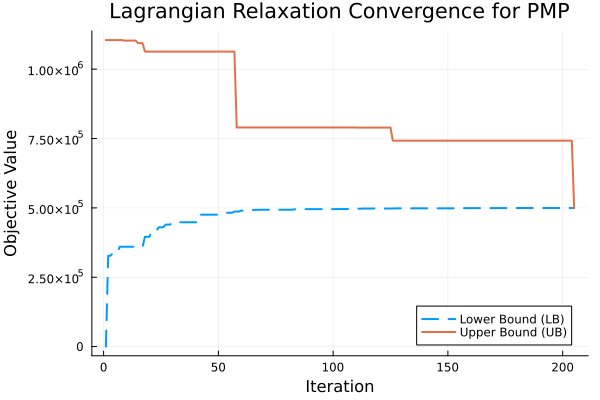

In [ ]:
# -------------------------------------------------------------
#  Code for: "Introduction to Integer Programming and Applications with Julia"
#  Chapter: 7 – Lagrangian relaxation
#  Section: Exercise 2.1
#  Author(s): Luiz Henrique Nogueira Lorena
# -------------------------------------------------------------

using JuMP            # For mathematical programming
using HiGHS           # HiGHS solver
using CSV             # For reading CSV files
using DataFrames      # For handling DataFrame operations
using Distances       # Distance computations
using LinearAlgebra   # For norm calculations
using Printf          # For formatted output
using Plots           # For plotting

# Function to plot convergence of LB and UB
function plot_convergence(lb_history, ub_history)
    p = plot(1:length(lb_history), [lb_history ub_history],
        label=["Lower Bound (LB)" "Upper Bound (UB)"],
        xlabel="Iteration",
        ylabel="Objective Value",
        title="Lagrangian Relaxation Convergence for PMP",
        linewidth=2,
        linestyle=[:dash :solid],
        legend=:bottomright)
    display(p)
end

# Function to solve the p-median problem exactly
function solve_pmedian_exact(distance_matrix, p)
    n = size(distance_matrix, 1)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Variables
    @variable(model, x[1:n, 1:n], Bin)  
    # Objective: Minimize total distance
    @objective(model, Min, sum(distance_matrix[i,j] * x[i,j] for i in 1:n, j in 1:n))
    # Constraint: Each customer assigned to one facility
    @constraint(model, [i=1:n], sum(x[i,j] for j in 1:n) == 1)
    # Constraint: Assignment only to open facilities
    @constraint(model, [i=1:n, j=1:n], x[i,j] <= x[j,j])
    # Constraint: Exactly p facilities opened
    @constraint(model, sum(x[j,j] for j in 1:n) == p)
    # Run the solver 
    JuMP.optimize!(model)
    # Return the optimal value
    if termination_status(model) == JuMP.OPTIMAL
        return JuMP.objective_value(model)
    else
        error("Optimal solution not found.")
    end
end

# Main function to solve p-median problem using Lagrangian Relaxation
function solve_pmedian_lagrangian(file_path; p = 3, iterations = 100, gap_tolerance = 0.0001)

    # Load latitude and longitude data
    coordinates = CSV.read(file_path, header=true, DataFrame) |> Matrix{Float64}
    
    # Compute Haversine distance matrix
    distance_matrix = Distances.pairwise(Distances.Haversine(), coordinates, dims=1)

    # Algorithm Initialization
    n = size(distance_matrix, 1) # Number of clients / facilities
    λ = zeros(n)                 # Lagrange multipliers
    θ = 0.8                      # A factor to update multiplier (Held-Karp)
    LB = -Inf                    # Best lower bound found so far
    UB = Inf                     # Best upper bound found so far
    LB_history = []              # Store lower bound history
    UB_history = []              # Store upper bound history

    # Counter logic for robust convergence: reduce θ after 10 iterations without improvement in LB
    no_improve_limit = 10
    no_improve_counter = 0

    println("--- Starting Lagrangian Relaxation for fault-tolerant p-median ---")
    println("Iter. |     Lower Bound     |     Upper Bound     |     Gap (%)")
    println("-"^66)

    for iteration in 1:iterations
        # ---- 1. Solve the relaxed problem to get a lower bound

        # 1a. Modify costs with current λ
        modified_costs = distance_matrix .- λ

        # 1b. Calculate attractiveness for each facility
        facility_costs = vec(sum(min.(0.0, modified_costs), dims=1))

        # 1c. Select p facilities with lowest modified cost
        chosen_facilities = sortperm(facility_costs)[1:p]

        # 1d. Calculate the relaxed solution
        x_k = zeros(Int, n, n)
        for j in chosen_facilities
            mask = modified_costs[:, j] .< 0
            x_k[mask, j] .= 1
        end

        # 1e. Calculate Lagrangian Lower Bound
        current_LB = sum(facility_costs[chosen_facilities]) + sum(λ)

        # 1f. Update the Best Lower Bound (LB)
        if current_LB > LB
            LB = current_LB
            no_improve_counter = 0
        else
            no_improve_counter += 1
            # Held-Karp Rule: Reduce θ if progress stalls
            if no_improve_counter >= no_improve_limit
                θ *= 0.5
                no_improve_counter = 0
            end
        end
        push!(LB_history, LB)

        # --- 2. Generate a Feasible Solution (Heuristic for Upper Bound) ---

        # 2a. For each customer, assign them to the *closest* open facility
        current_UB = sum([minimum(distance_matrix[i, chosen_facilities]) for i in 1:n])

        # 2b. Update the best upper bound if this heuristic solution is better
        UB = min(UB, current_UB)

        # 2c. Store upper bound history
        push!(UB_history, UB)

        # --- 3. Subgradient update ---

        # 3a. Calculate subgradient
        g = ones(n) - sum(x_k, dims=2)[:]

        # 3b. If subgradient is close to zero, we might have an optimal solution
        if norm(g) < 1e-6
            @printf("%5d | %19.3f | %19.3f | %9.3f\n", iteration, LB, UB, ((UB - LB) / UB) * 100)
            println("Subgradient norm is zero. Stopping.")
            break
        end

        # 3c. Determine the step size α_k (Held-Karp style)
        α = θ * (UB - LB) / (norm(g)^2)

        # 3d. Update the multipliers
        λ .+= α .* g

        # Print iteration results
        if iteration % 10 == 1
            @printf("%5d | %19.3f | %19.3f | %9.3f\n", iteration, LB, UB, ((UB - LB) / UB) * 100)
        end

        # 3e. Check convergence
        gap = isfinite(UB) ? (UB - LB) / UB : Inf
        if isfinite(gap) && gap <= gap_tolerance
            @printf("%5d | %19.3f | %19.3f | %9.3f\n", iteration, LB, UB, gap * 100)
            println("Convergence achieved: Duality gap is below tolerance.")
            break
        end
    end

    # Final summary and Exact solve for comparison
    exact_objective = solve_pmedian_exact(distance_matrix, p)
    println("-"^66)
    println("Solving exact PMP for comparison...")
    # println("Final LB: $LB | Exact : $exact_objective | Duality Gap: $(abs(exact_objective - LB))")
    @printf("Final LB: %8.3f | Exact: %8.3f | Duality Gap: %5.3f (%5.3f%%)\n", LB, exact_objective, (exact_objective - LB), ((exact_objective - LB) / exact_objective) * 100)

    # Plot convergence
    plot_convergence(LB_history, UB_history)
end

# Example usage
solve_pmedian_lagrangian("data/exercise_pmp.csv", p = 3, iterations = 500, gap_tolerance = 1e-6)